In [1]:
# %pip install numpy==2.0.2 torch==2.10.0 torchvision==0.25.0 tqdm==4.67.3 scikit-learn==1.6.1 matplotlib==3.10.0

Part 1

In [2]:
import os
import time
import random
import numpy as np
from tqdm import tqdm
from copy import deepcopy
from sklearn.model_selection import train_test_split

import torch
import torch.nn.functional as F

import torchvision
from torchvision import transforms as T

import matplotlib.pyplot as plt



In [3]:
# seed everything for reproducibility
SEED = 42

def seed_everything(seed: int=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

Part 2

In [4]:
# define the transform to apply to the data - resize to 224x224 and convert to tensor.
transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])

# Load the datasets
path_where_data_is_stored = '../data' # change this to the path where you want to store the data

### START CODE HERE ### (≈ 2 lines) you need to load train and test `GTSRB` dataset from PyTorch official page.
full_dataset = torchvision.datasets.GTSRB(root=path_where_data_is_stored, split='train', download=True, transform=transform)
dataset_test = torchvision.datasets.GTSRB(root=path_where_data_is_stored, split='test', download=True, transform=transform)
### END CODE HERE ###

# Lets now split the dataset into a SSL dataset and a classification dataset
SSL_SIZE = 0.6 # percentage of the dataset to use for training
targets = np.array([y for _, y in full_dataset])
SSL_indices, classification_indices = train_test_split(
    np.arange(len(targets)),
    test_size=1-SSL_SIZE,
    random_state=SEED,
    stratify=targets
)
SSL_dataset = torch.utils.data.Subset(full_dataset, SSL_indices)
classification_dataset = torch.utils.data.Subset(full_dataset, classification_indices)

print(f"Train full dataset size: {len(full_dataset)}")
print(f"Train SSL dataset size: {len(SSL_dataset)}")
print(f"Train classification dataset size: {len(classification_dataset)}")
print(f"Test dataset size: {len(dataset_test)}")

Train full dataset size: 26640
Train SSL dataset size: 15984
Train classification dataset size: 10656
Test dataset size: 12630


In [5]:
map_idx_to_class = [
    "Speed limit (20km/h)",
    "Speed limit (30km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "End of speed limit (80km/h)",
    "Speed limit (100km/h)",
    "Speed limit (120km/h)",
    "No passing",
    "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 metric tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 metric tons"
]
angles = [0, 90, 180, 270]

In [6]:
image, target = next(iter(SSL_dataset))
image.shape, target, len(map_idx_to_class), len(angles)

(torch.Size([3, 224, 224]), 8, 43, 4)

In [7]:
# Rotation Dataset
class SSLRot(torch.utils.data.Dataset):
    def __init__(self, dataset: torch.utils.data.Dataset, angles: list[int]):
        super(SSLRot, self).__init__()
        self.original_dataset = dataset
        self.angles = angles

    def __len__(self):
        return len(self.original_dataset)

    def rand_rotate(self, img: torch.Tensor) -> tuple[torch.Tensor, int]:
        """
        Randomly rotates the image by 0, 90, 180, or 270 degrees.

        Args:
            img (torch.Tensor): Input image tensor of shape (C, H, W).

        Returns:
            tuple: Rotated image tensor and the corresponding rotation label (0, 1, 2, or 3).
        """
        ### START CODE HERE ###

        label = np.random.randint(0,4)
        rotated_img = torch.rot90(img, k=label, dims=[1, 2])

        return rotated_img,label
        ### END CODE HERE ###

    def __getitem__(self, idx):
        ### START CODE HERE ###
        # Get the data from the original dataset and ignore the label (second element)
        img, _ = self.original_dataset[idx]
        rotated_img, rot_label = self.rand_rotate(img)
        ### END CODE HERE ###
        return rotated_img, torch.tensor(rot_label, dtype=torch.long)

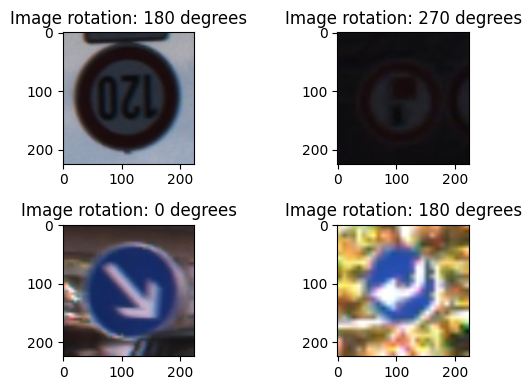

In [8]:
rotation_dataset_train = SSLRot(SSL_dataset, angles)
rotation_dataset_test = SSLRot(dataset_test, angles)

fig, ax = plt.subplots(2, 2, figsize=(6, 4))
img, rot = rotation_dataset_train[0]
ax[0, 0].imshow(img.permute(1, 2, 0))
ax[0, 0].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_train[1]
ax[0, 1].imshow(img.permute(1, 2, 0))
ax[0, 1].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_test[2]
ax[1, 0].imshow(img.permute(1, 2, 0))
ax[1, 0].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_test[3]
ax[1, 1].imshow(img.permute(1, 2, 0))
ax[1, 1].set_title(f"Image rotation: {angles[rot]} degrees")
plt.tight_layout()
plt.show()

Part 3

In [9]:
def load_resnet_rotation(number_of_classes=4):
    ### START CODE HERE ### (≈ 2 lines)
    # Load ResNet18 without pre-trained weights from Pytorch page
    # Modify the final fully connected layer to output 4 classes (rotation labels).
    # If you don't know how to modify the last layer, in the previous exercise tutorial there was a part where authors modified the last layer of ResNet18 to output 2 classes.
    ### END CODE HERE ###
    model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, number_of_classes)
    return model

def test_load_resnet_rotation():
    model = load_resnet_rotation()
    x, y = rotation_dataset_train[0]
    x = x.unsqueeze(0)  # Add a batch dimension
    y = y.unsqueeze(0)  # Add a batch dimension

    with torch.no_grad():
        pred_y = model(x)

    loss = F.cross_entropy(pred_y, y)
    pred_y_class = torch.argmax(pred_y, dim=1)
    print(f"Input shape: {x.shape}, Model output: {pred_y.shape}, Model predicted {pred_y_class}, Ground truth: {y}, Loss: {loss.item()}")

test_load_resnet_rotation()

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Input shape: torch.Size([1, 3, 224, 224]), Model output: torch.Size([1, 4]), Model predicted tensor([3]), Ground truth: tensor([2]), Loss: 1.8601665496826172


Part 4

In [10]:
def train_one_epoch(model: torch.nn.Module, optimizer: torch.optim.Optimizer, train_loader: torch.utils.data.DataLoader, criterion: torch.nn.Module, device=torch.device):
    """Train the model for one epoch.
    Args:
        model (torch.nn.Module): The model to train.
        optimizer (torch.optim.Optimizer): The optimizer to use.
        train_loader (torch.utils.data.DataLoader): The training data loader.
        criterion (torch.nn.Module): The loss function.
        device (torch.device): The device to use for training (CPU or GPU).
    Returns:
        tuple: The average loss and accuracy for the epoch.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in tqdm(train_loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = total_loss / total
    train_acc = 100.0 * correct / total

    return train_loss, train_acc

def validate(model: torch.nn.Module, val_loader: torch.utils.data.DataLoader, device=torch.device) -> float:
    """Validate the model.
    Args:
        model (nn.Module): The model to validate.
        val_loader (torch.utils.data.DataLoader): The validation data loader.
        device (torch.device): The device to use for validation (CPU or GPU).

    Returns:
        float: The average accuracy for the validation set.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc="Validating"):
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward
            outputs = model(inputs)

            # Statistics
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_acc = 100.0 * correct / total

    return val_acc

def visualize_predictions(model: torch.nn.Module, dataset: torch.utils.data.Dataset, device: torch.device, class_names: list[str], num_images: int=5):
    """Visualize predictions of the model on a subset of the dataset.
    Args:
        model (torch.nn.Module): The model to use for predictions.
        dataset (torch.utils.data.Dataset): The dataset to visualize.
        device (torch.device): The device to use for predictions (CPU or GPU).
        class_names (list[str]): The list of class names.
        num_images (int): The number of images to visualize.

    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    _, axes = plt.subplots(1, num_images, figsize=(15, 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            img = img.unsqueeze(0).to(device)
            output = model(img)
            pred_label = output.argmax(dim=1).item()

            axes[i].imshow(img.squeeze(0).permute(1, 2, 0).cpu())
            axes[i].set_title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[label]}")
            axes[i].axis('off')

    plt.show()

In [11]:
def train(model: torch.nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, criterion: torch.nn.Module, num_epochs: int=10, device=torch.device) -> tuple[list[float], list[float]]:
    """Train the model.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (torch.utils.data.DataLoader): The training data loader.
        val_loader (torch.utils.data.DataLoader): The validation data loader.
        optimizer (torch.optim.Optimizer): The optimizer to use.
        criterion (torch.nn.Module): The loss function.
        num_epochs (int): The number of epochs to train for.
        device (torch.device): The device to use for training (CPU or GPU).

    Returns:
        tuple: A tuple containing the training losses and validation accuracies for each epoch.
    """
    train_accs = []
    val_accs = []
    ### START CODE HERE ###


    for i in range(num_epochs):
      if i %10:
        print(f"epoch {i}" )
      loss, tmp_acc_train = train_one_epoch(model, optimizer, train_loader, criterion, device)
      train_accs.append(tmp_acc_train)
      tmp_acc_val= validate(model, val_loader, device)
      val_accs.append(tmp_acc_val)


    ### END CODE HERE ###
    return train_accs, val_accs

In [12]:

BATCH_SIZE = 64
NUM_EPOCHS = 4
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(rotation_dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(rotation_dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Load the model
ssl_model = load_resnet_rotation(NUMBER_OF_CLASSES)
ssl_model = ssl_model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(ssl_model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)
print(train_accs[-1])
print(val_accs[-1])

### START CODE HERE ### (≈ 1 lines)
torch.save({'model_state_dict': ssl_model.state_dict(), 'train_accs': train_accs, 'val_accs': val_accs}, 'ssl_resnet18_rotation.pth')
### END CODE HERE ###

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Validating: 100%|██████████| 198/198 [00:32<00:00,  6.00it/s]


epoch 1


Validating: 100%|██████████| 198/198 [00:32<00:00,  6.13it/s]


epoch 2


Validating: 100%|██████████| 198/198 [00:33<00:00,  5.95it/s]


epoch 3


Validating: 100%|██████████| 198/198 [00:33<00:00,  5.90it/s]

93.78753753753753
93.76880443388757


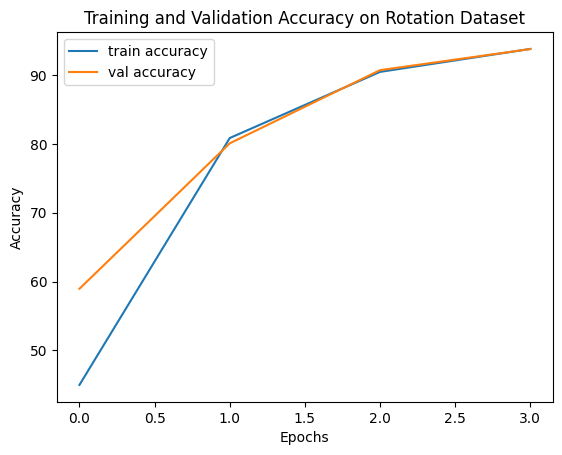

In [14]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on Rotation Dataset')
plt.legend()
plt.show()

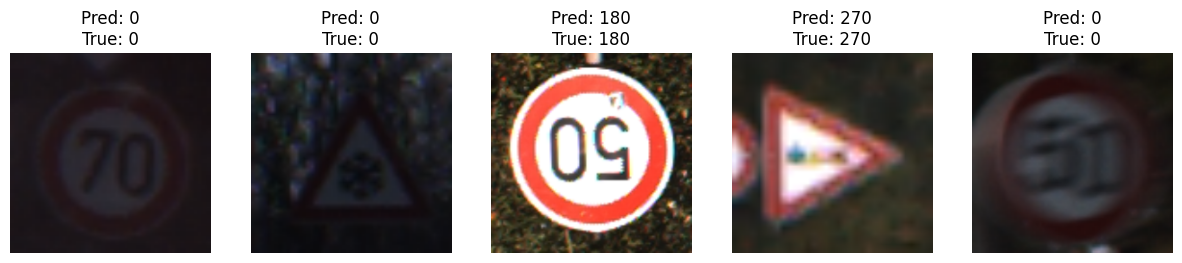

In [15]:
visualize_predictions(ssl_model, rotation_dataset_test, num_images=5, device=device, class_names=angles)

Part 5

In [16]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 6
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Load the model
empty_model = load_resnet_rotation(NUMBER_OF_CLASSES)
empty_model = empty_model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(empty_model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(empty_model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)
print(train_accs[-1])
print(val_accs[-1])

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Validating: 100%|██████████| 198/198 [00:30<00:00,  6.50it/s]


epoch 1


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.66it/s]


epoch 2


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.67it/s]


...

epoch 4


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.70it/s]


epoch 5


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.69it/s]

99.57770270270271
92.32779097387173


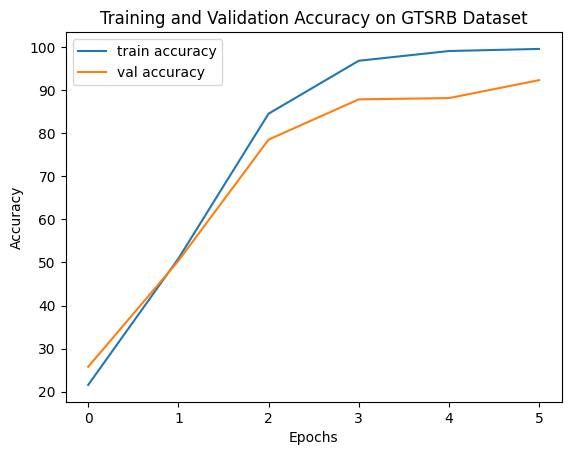

In [18]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset')
plt.legend()
plt.show()

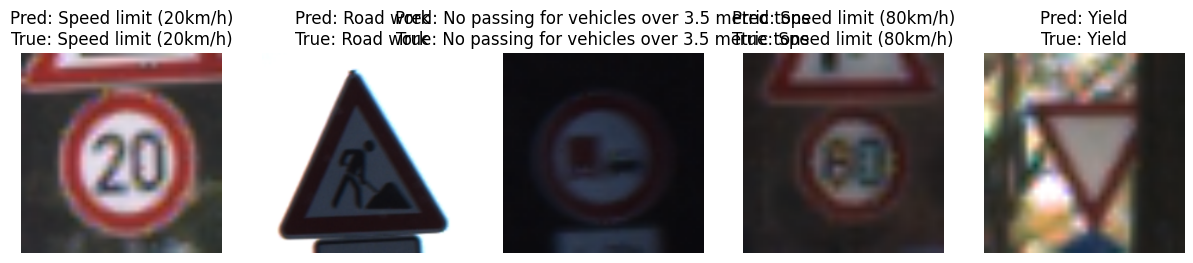

In [19]:
visualize_predictions(empty_model, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

Part 6



In [20]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Freeze the model
model = deepcopy(ssl_model)

### CODE HERE ### (≈ 3 lines) freeze the whole model and substitute the last layer with a new one that has the number of classes equal to `NUMBER_OF_CLASSES`.

for param in ssl_model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(ssl_model.fc.in_features, NUMBER_OF_CLASSES)

### END CODE HERE ###
model = model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)
print(train_accs[-1])
print(val_accs[-1])

Validating: 100%|██████████| 198/198 [00:30<00:00,  6.54it/s]


epoch 1


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.67it/s]


epoch 2


Validating: 100%|██████████| 198/198 [00:29<00:00,  6.65it/s]


...

epoch 18


Validating: 100%|██████████| 198/198 [00:30<00:00,  6.45it/s]


epoch 19


Validating: 100%|██████████| 198/198 [00:31<00:00,  6.34it/s]

100.0
98.13935075217735


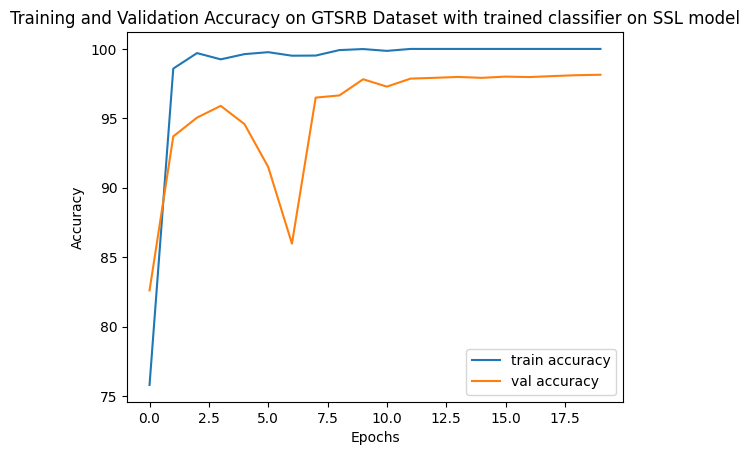

In [22]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset with trained classifier on SSL model')
plt.legend()
plt.show()

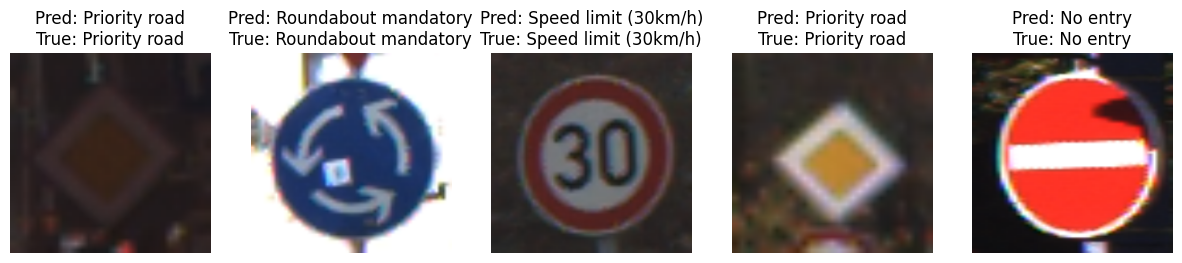

In [23]:
visualize_predictions(model, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

Part 7

In [24]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 4
LEARNING_RATE = 0.0001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [25]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Freeze the model
model_finetune = deepcopy(ssl_model)

### CODE HERE ### (≈ 1 line) substitute the last layer with a new one that has the number of classes equal to `NUMBER_OF_CLASSES`.
model_finetune.fc=torch.nn.Linear(ssl_model.fc.in_features, NUMBER_OF_CLASSES)
### END CODE HERE ###
model_finetune = model_finetune.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(model_finetune.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(model_finetune, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)
print(train_accs[-1])
print(val_accs[-1])

Validating: 100%|██████████| 198/198 [00:30<00:00,  6.53it/s]


epoch 1


Validating: 100%|██████████| 198/198 [00:30<00:00,  6.44it/s]


epoch 2


Validating: 100%|██████████| 198/198 [00:30<00:00,  6.49it/s]


epoch 3


Validating: 100%|██████████| 198/198 [00:30<00:00,  6.46it/s]

19.7728978978979
22.050673000791765


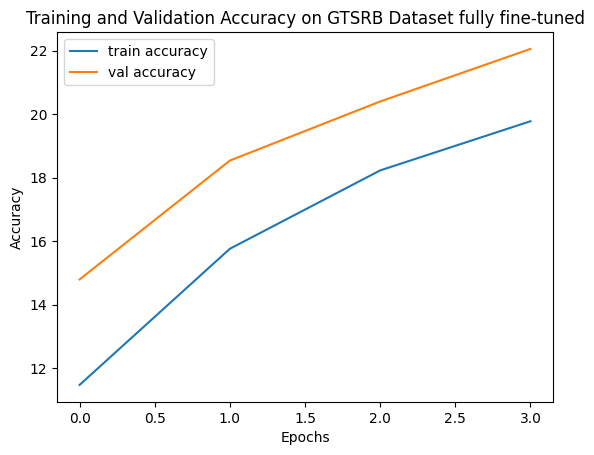

In [26]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset fully fine-tuned')
plt.legend()
plt.show()

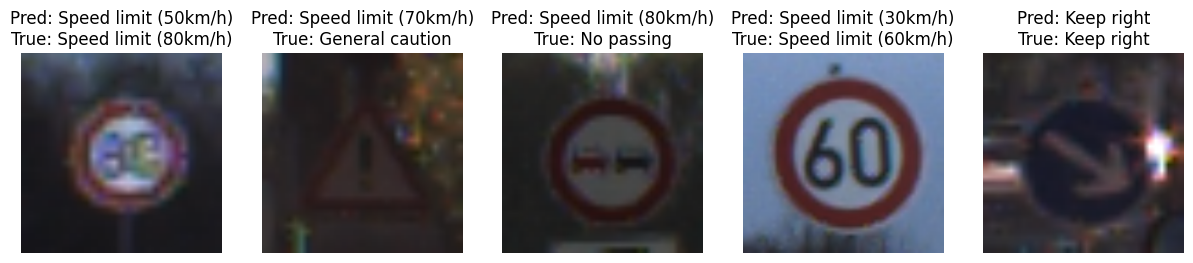

In [27]:
visualize_predictions(model_finetune, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

Part 8


| Metryka | SSL_SIZE = 60% | SSL_SIZE = 80% |
| :--- | :---: | :---: |
| **Liczba zdjęć w etapie SSL (nieopisane)** | ~23,525 | ~31,367 |
| **Liczba zdjęć w klasyfikacji (opisane)** | ~15,684 | ~7,842 |
| **SSL Rotation Accuracy (Test)** | 93.76880 % | [WPISZ]% |
| **Final Classification Accuracy (Test)** | 22.05067% | [WPISZ]% |

---

## Odpowiedzi na pytania

### SSL_SIZE = 60%
* **Czy model trenowany na SSL wypadł lepiej niż trenowany tylko na klasyfikacji?**

* **Która strategia zadziałała lepiej: trenowanie samej głowy czy fine-tuning?**

* **Jakie inne korzyści (poza accuracy) daje SSL?**

* **Wnioski i oczekiwania:**

* **Czy SSL był użyteczny?**


###SSL_SIZE = 80%
* **Czy model trenowany na SSL wypadł lepiej niż trenowany tylko na klasyfikacji?**

* **Która strategia zadziałała lepiej: trenowanie samej głowy czy fine-tuning?**

* **Jakie inne korzyści daje SSL?**

* **Wnioski i oczekiwania:**

* **Czy SSL był użyteczny?**


---

## Co się stało, gdy liczba etykietowanych danych spadła?
Zaobserwowano następujące zjawiska:

1.  **Zwiększenie jakości filtrów (Backbone):**
2.  **Trudniejsza klasyfikacja:**
3.  **Wniosek końcowy:**